In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from matplotlib.patches import ConnectionPatch
import numpy as np
import pandas as pd
import seaborn as sns
import datetime
import warnings


from scipy.stats import expon, reciprocal
from scipy.stats import randint
from scipy import stats

from pandas.plotting import scatter_matrix

from sklearn.manifold import TSNE
from sklearn.manifold import LocallyLinearEmbedding

from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA

from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering #kernel
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import FeatureAgglomeration
from sklearn.cluster import AffinityPropagation

from sklearn.mixture import BayesianGaussianMixture
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, roc_auc_score

from xgboost import XGBClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import permutation_test_score
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler # mean0 std1
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import ConvergenceWarning


from yellowbrick.cluster import KElbowVisualizer

%matplotlib inline

from  warnings import simplefilter
simplefilter("ignore", category=UserWarning)

<p style= "background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;border-style:solid;border-width:3px;border-color:#000000;"><b>Titanic Data Science</b></p>

## Please give me an UPVOTE if you can. Your UPVOTE will be a great encouragement to me

- The score is the result of combining multiple pipelines in the following code. We have removed some of the pipelines in the following code because we think it is not good for learning to put the score answers as they are.

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">Data Science Workflow</p>

# WorkFlow

1. Understand the framework and big picture of the problem.
2. Analyze the data to develop a personal understanding.
3. Prepare data to make it easier for machine learning algorithms to find patterns in the data.
4. Try different models and narrow it down to the best few.
5. Fine-tune the models, use them as an ensemble, and combine them into a solution.
6. Present the solution.

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">DATA Observation</p>

In [2]:
main_test = pd.read_csv('../input/titanic/test.csv')
main_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [3]:
data = pd.read_csv('../input/titanic/train.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
cluster_data_c = data.copy()
cluster_main_test = main_test.copy()

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">DATA Concatenation</p>

>Merge the pre-divided data sets. This operation makes it possible to make the same changes during data conversion.

In [5]:
cluster_data = pd.concat([cluster_data_c, cluster_main_test], axis=0)
cluster_data.describe().T.style.bar(subset=['mean'], color='#606ff2').background_gradient(subset=['std'], cmap='mako_r').background_gradient(subset=['50%'], cmap='mako_r')

,count,mean,std,min,25%,50%,75%,max
PassengerId,1309.000000,655.000000,378.020061,1.000000,328.000000,655.000000,982.000000,1309.000000
Survived,891.000000,0.383838,0.486592,0.000000,0.000000,0.000000,1.000000,1.000000
Pclass,1309.000000,2.294882,0.837836,1.000000,2.000000,3.000000,3.000000,3.000000
Age,1046.000000,29.881138,14.413493,0.170000,21.000000,28.000000,39.000000,80.000000
SibSp,1309.000000,0.498854,1.041658,0.000000,0.000000,0.000000,1.000000,8.000000
Parch,1309.000000,0.385027,0.865560,0.000000,0.000000,0.000000,0.000000,9.000000
Fare,1308.000000,33.295479,51.758668,0.000000,7.895800,14.454200,31.275000,512.329200


<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">EDA</p>

# EDA

1. Make a copy of the data for observation, or reduce it to the required size if the data is large.
2. examine the attributes of the data and their characteristics
    - Missing values
    - Categorical/textual/integer/floating point numbers
    - Noise presence and type (stochastic, outlier, rounding error)
    - Type of distribution (Gaussian, Uniform, Logarithmic)
3. visualize the data
4. examine correlation of features
5. Identify the transformation to be applied

In [6]:
eda_data = data.reset_index().copy()

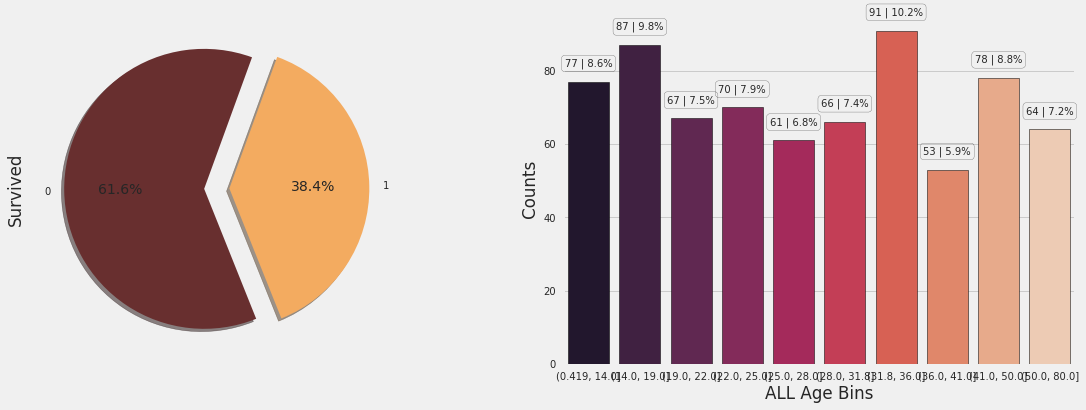

In [7]:
with plt.style.context('fivethirtyeight'): # background color set rcPram
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    eda_data['Survived'].value_counts().plot.pie(explode=[0, 0.18], autopct='%1.1f%%',
                                                 shadow=True, colors=['#682F2F', '#F3AB60'], startangle=70, ax=ax[0])
    
    age_bin = pd.qcut(eda_data['Age'], 10)
    age_counts = sns.barplot(x=age_bin.sort_index().value_counts().index, y=age_bin.value_counts().values,
                             linewidth=0.5, ec='black', zorder=3, palette='rocket', ax=ax[1])
    for i in age_counts.patches:
        values = f'{i.get_height():,.0f} | {i.get_height() / age_bin.shape[0]:,.1%}'
        x = i.get_x() + i.get_width() / 2
        y = i.get_y() + i.get_height() + 5
        age_counts.text(x, y, values, ha='center', va='center', fontsize=10, 
                        bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.2))
        ax[1].set_xlabel('ALL Age Bins')
        ax[1].set_ylabel('Counts')

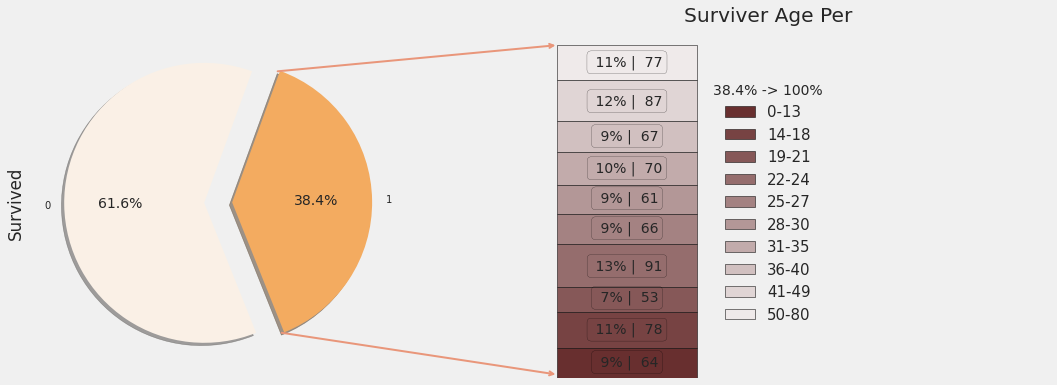

In [8]:
with plt.style.context('fivethirtyeight'): # background color set
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.subplots_adjust(wspace=0)
    eda_data['Survived'].value_counts().plot.pie(explode=[0, 0.2], autopct='%1.1f%%',
                                                 shadow=True, colors=['#faf0e6', '#F3AB60'], startangle=70, ax=ax1)
    
    colors = ['#682f2f', '#774343', '#865858', '#956D6D', '#A48282',
              '#B39797', '#C2ABAB', '#D1C0C0', '#E0D5D5', '#EFEAEA']
    bar_per = eda_data['Survived'].groupby(age_bin).count()[::-1]
    bottom = 0
    for i in range(len(bar_per.values)):
        height = bar_per.values[i] / bar_per.values.sum()
        ax2.bar(-0.2, height=height, width=.2 ,bottom=bottom, color=colors[i], edgecolor='black')
        y = bottom + ax2.patches[i].get_height() / 2.5
        bottom += height
        values = f'{ax2.patches[i].get_height(): ,.0%} | {bar_per.values[i]: ,.0f}' # "%d%%" % (ax2.patches[i].get_height() *100)
        ax2.text(-0.2, y, values, ha='center',
                 bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.2))

    ax2.set_title('Surviver Age Per')
    # reversed legend
    ax2.legend(('0-13', '14-18', '19-21', '22-24', '25-27','28-30', '31-35', '36-40', '41-49', '50-80'), 
               title='38.4% -> 100%', loc='center', prop={'size':15})
    ax2.axis('off')
    ax2.set_xlim(-2.0 * .2, 2.0 * .2)

    theta1, theta2 = ax1.patches[0].theta1, ax1.patches[0].theta2
    center, r = ax1.patches[0].center, ax1.patches[0].r
    
    x = r * np.cos(np.pi / 173 * theta2) + center[0]
    y = r * np.sin(np.pi / 180 * theta2) + center[1]
    con = ConnectionPatch(xyA=(-.3, 0.01), xyB=(x, y), coordsA=ax2.transData, coordsB=ax1.transData, shrinkA=1, arrowstyle='<-')
    con.set_color('#e9967a')#e9967a
    con.set_linewidth(2)
    ax2.add_artist(con)

    x = r * np.cos(np.pi / 216 * theta1) + center[0]
    y = r * np.sin(np.pi / 180 * theta1) + center[1]
    con = ConnectionPatch(xyA=(-.3, 0.998), xyB=(x, y), coordsA=ax2.transData, coordsB=ax1.transData, shrinkA=1, arrowstyle='<-')
    con.set_color('#e9967a')#e9967a
    ax2.add_artist(con)
    con.set_linewidth(2)

In [9]:
def ms_pair_plot(values, hue='Survived'):
    with plt.style.context('fivethirtyeight'):
        fig, ax = plt.subplots(1, 2, figsize=(18, 6))
        for i in range(len(values)):
            #fig, ax = plt.subplots(1, 2, figsize=(18, 6)) when plot_buplication is performed, inclusion 
            value = values[i]
            sns.histplot(x=value, hue=hue, data=eda_data, kde=True, palette='rocket', ax=ax[i])
            ax[i].axvline(x=eda_data[value].mean(), color='g', linestyle='--', linewidth=3)
            ax[i].axvline(x=eda_data[value].std(), color='c', linestyle=':', linewidth=3)
            ax[i].text(eda_data[value].mean(), eda_data[value].mean(), "<--Mean", horizontalalignment='left', size='small', color='black', weight='semibold')
            ax[i].text(eda_data[value].std(), eda_data[value].std(), "Std-->", horizontalalignment='right', size='small', color='black', weight='semibold')
            sns.despine()

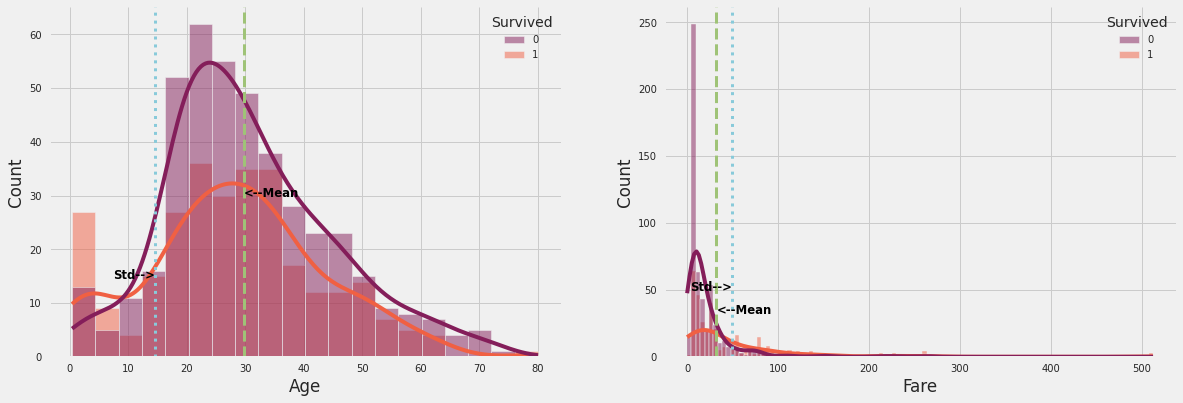

In [10]:
values = ['Age', 'Fare']
ms_pair_plot(values)

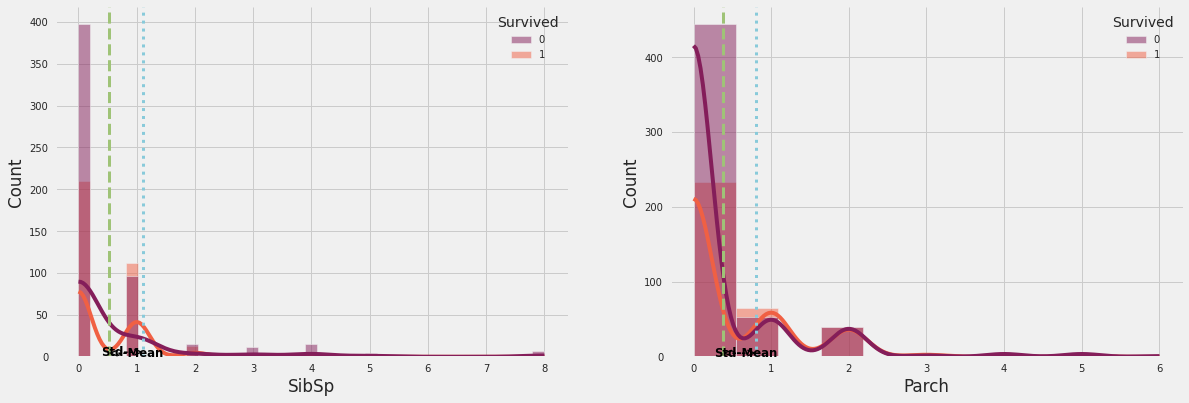

In [11]:
values = ['SibSp', 'Parch']
ms_pair_plot(values)

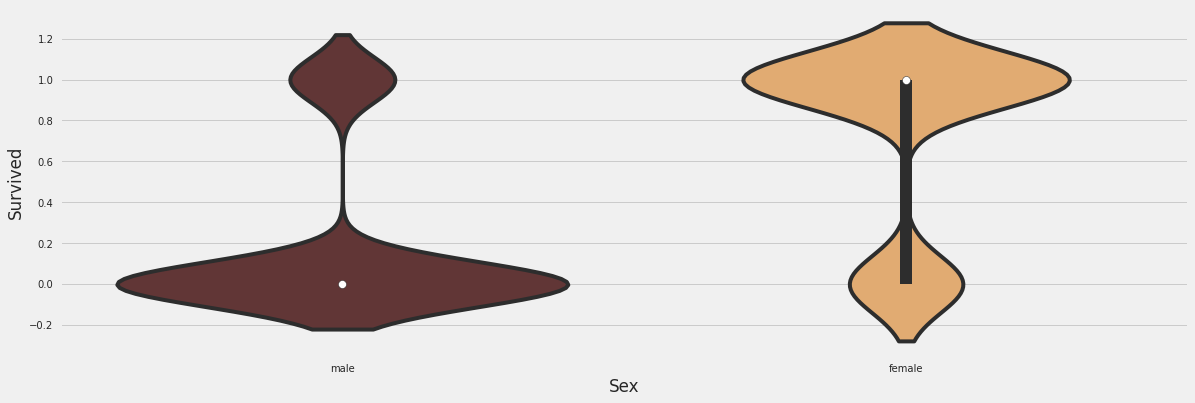

In [12]:
with plt.style.context('fivethirtyeight'):
    fig = plt.figure(figsize=(18, 6))
    sns.violinplot(x="Sex", y="Survived", data=eda_data, palette=['#682F2F', '#F3AB60'])
    #plt.ylim(-50, 200)

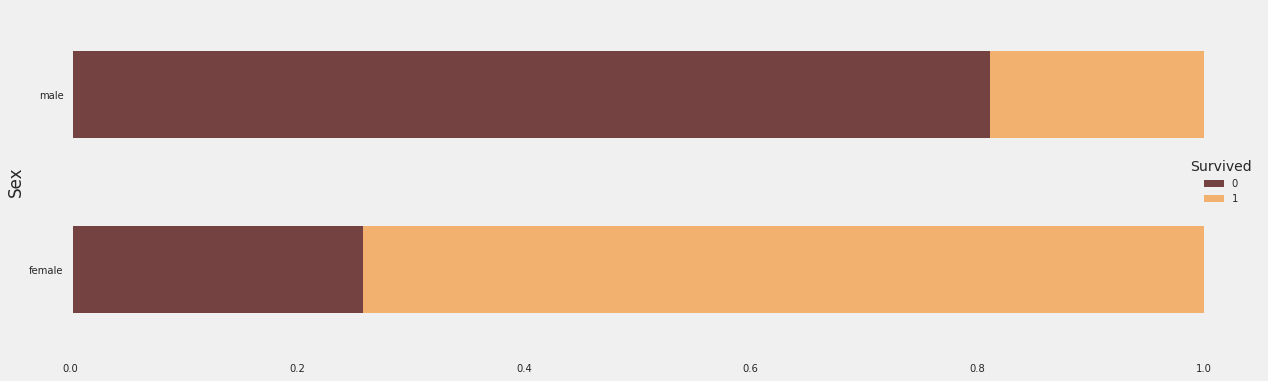

In [13]:
survived_count = pd.crosstab(eda_data['Sex'], eda_data['Survived'])
survived_pct = survived_count.div(survived_count.sum(1), axis=0)
with plt.style.context('fivethirtyeight'):
    survived_pct.plot.barh(stacked=True, figsize=(19, 6), alpha=0.9, grid=False, color=['#682F2F', '#F3AB60'])

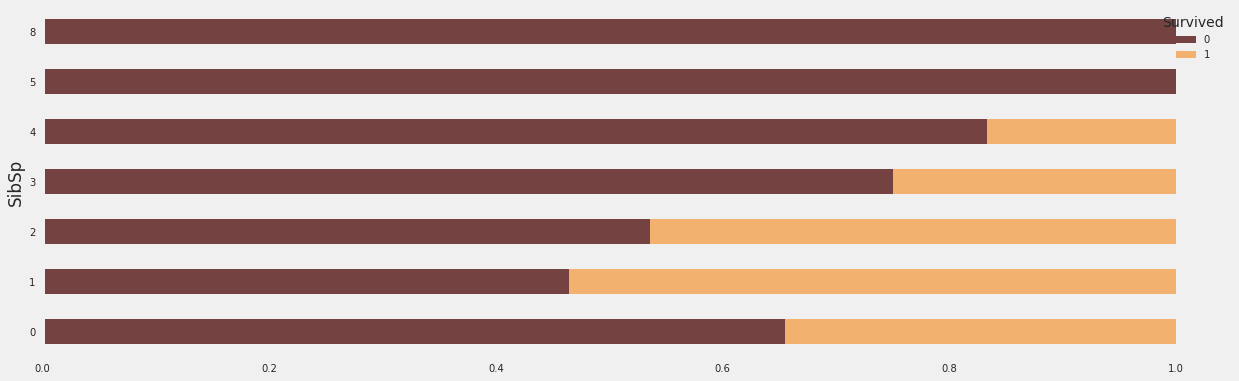

In [14]:
survived_count = pd.crosstab(eda_data['SibSp'], eda_data['Survived'])
survived_pct = survived_count.div(survived_count.sum(1), axis=0)
with plt.style.context('fivethirtyeight'):
    survived_pct.plot.barh(stacked=True, figsize=(19, 6), alpha=0.9, grid=False, color=['#682F2F', '#F3AB60'])

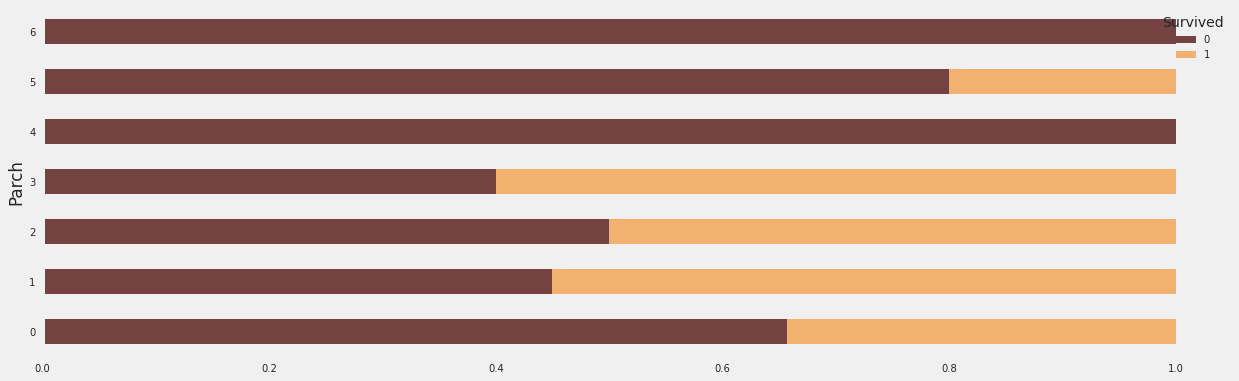

In [15]:
survived_count = pd.crosstab(eda_data['Parch'], eda_data['Survived'])
survived_pct = survived_count.div(survived_count.sum(1), axis=0)
with plt.style.context('fivethirtyeight'):
    survived_pct.plot.barh(stacked=True, figsize=(19, 6), alpha=0.9, grid=False, color=['#682F2F', '#F3AB60'])

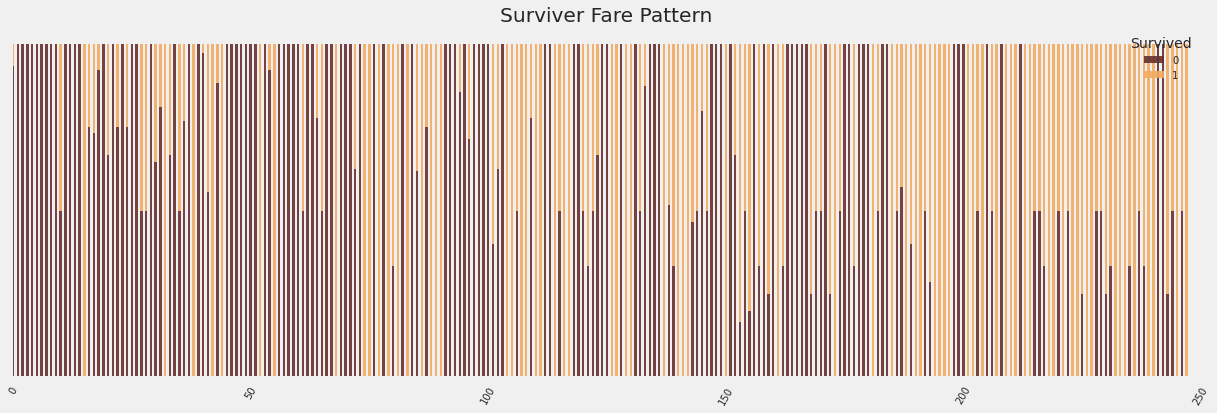

In [16]:
survived_count = pd.crosstab(eda_data['Fare'], eda_data['Survived'])
survived_pct = survived_count.div(survived_count.sum(1), axis=0)
with plt.style.context('fivethirtyeight'):
    survived_pct.plot.bar(stacked=True, alpha=0.9, figsize=(19, 6),
                          grid=False, use_index=None, logy=False,
                          rot=60, yticks=[], xticks=range(0, 251, 50),
                          title='Surviver Fare Pattern', color=['#682F2F', '#F3AB60'])

In [17]:
def trimming_ax(ax, N):
    f_axs = ax.flat
    for ax in f_axs[N:]:
        ax.remove()
    return f_axs[:N]

def cluster_bar_plot(data, product_list, cols=3, figsize=(19, 6)):
    product_list.append('')
    length = len(product_list)
    product_list.remove('')
    if length % 2 == 0:
        rows = length // cols
    else:
        rows = length // cols + 1
    with plt.style.context('fivethirtyeight'):
        
        ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(rows, cols)
        ax = trimming_ax(ax, length)
        for i, product in enumerate(product_list):
            cluster = data.query("Survived == {}".format(i))
            
            sns.barplot(x="Survived", y=product, data=data, palette='rocket', ax=ax[i])
            ax[i].legend(labels=['{}'.format(product)], title='P', loc=2, bbox_to_anchor=(1,1))
        
            sns.boxenplot(x="Survived", y="Fare", data=data, palette='rocket', ax=ax[-1])
            ax[-1].legend(labels=['Survived'], title='Survived_Number', loc=2, bbox_to_anchor=(1,1))

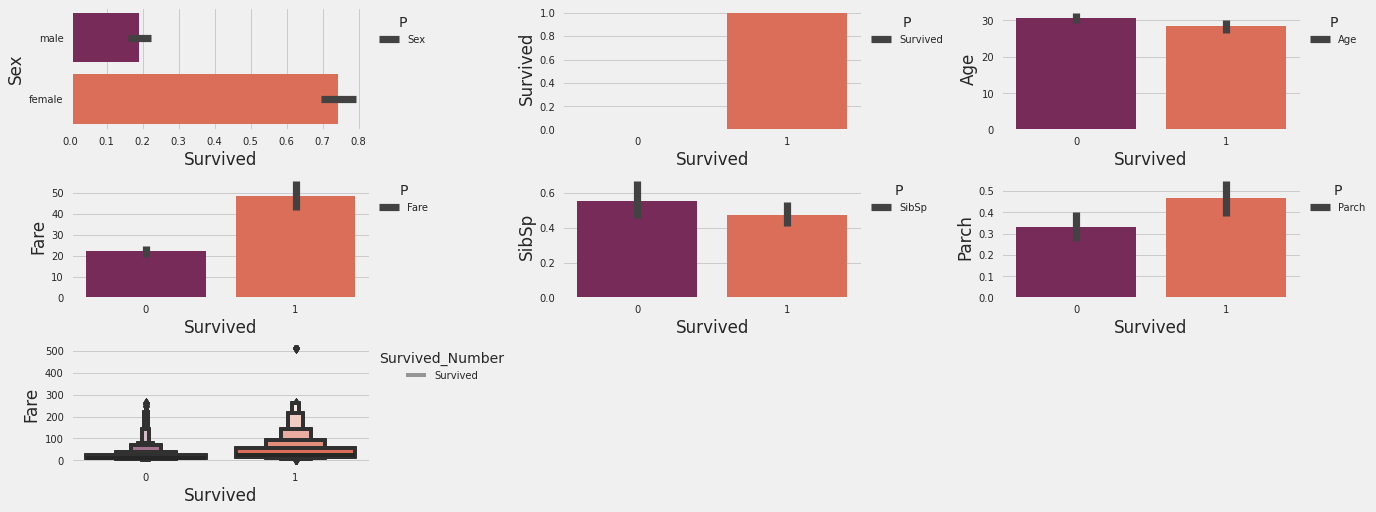

In [18]:
product_List = ['Sex','Survived', 'Age', 'Fare', 'SibSp','Parch']


cluster_bar_plot(eda_data, product_List, figsize=(19, 7))

In [19]:
def Survived_hist_plot(data, columns, cols=4, figsize=(10, 5)):
    #cols = cols
    rows = len(np.unique(data['Survived'])) // cols + 1
    bins = np.round(np.log(len(data)) + 1).astype(int) # Sturgess Formula : k=log2N+1
    ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(rows, cols)
    ax = trimming_ax(ax, len(np.unique(data['Survived'])))
    with plt.style.context('fivethirtyeight'):
        for i in np.unique(data['Survived']):
            cluster = data.query("Survived == {}".format(i))
            # replace plot
            sns.histplot(x=columns, data=cluster.reset_index(), bins=bins, ax=ax[i])
            #sns.countplot(x='Age', data=cluster.reset_index(), ax=ax[i])
            ax[i].legend(labels=['{}'.format(i)], title='Survived', loc=2, bbox_to_anchor=(1,1))

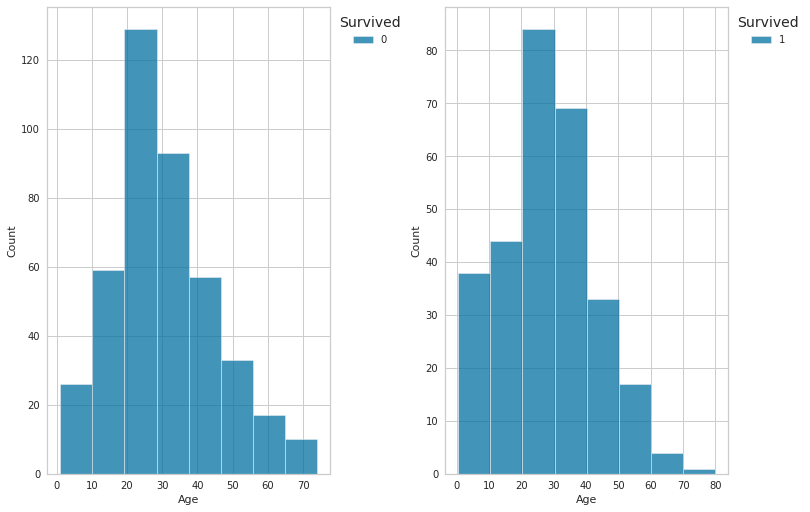

In [20]:
Survived_hist_plot(eda_data, columns='Age', figsize=(19, 7))

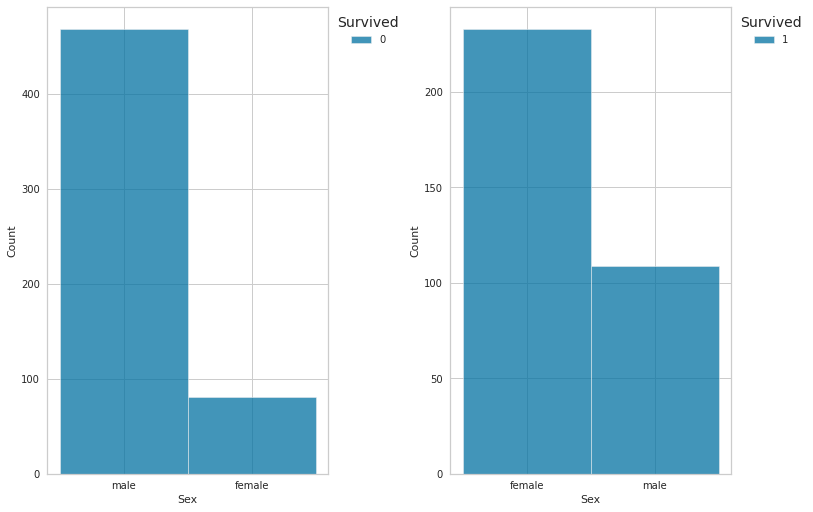

In [21]:
Survived_hist_plot(eda_data, columns='Sex', figsize=(19, 7))

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">Other Data Plot</p>

#### ・Data Plot & Normalization
#### ・Dendrogram & HeatMap

In [22]:
def density_plot(data):
    density_per_col = [stats.gaussian_kde(col) for col in data.values.T]
    x = np.linspace(np.min(data.values), np.max(data.values), 100)
    
    with plt.style.context('fivethirtyeight'):
        fig, ax = plt.subplots(figsize=(18, 6))
        for density in density_per_col:
            ax.plot(x, density(x))
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        fig.legend(data, loc='right')

In [23]:
counts = data.copy()
counts.reset_index(inplace=True)
counts.drop(['Name', 'Cabin', 'Ticket', 'PassengerId', 'Sex', 'Embarked'], axis=1, inplace=True)
counts.fillna(0, inplace=True)
counts_nd = counts.values
log_counts = np.log(counts_nd + 1)
log_counts_pd = pd.DataFrame(log_counts, columns=counts.columns)

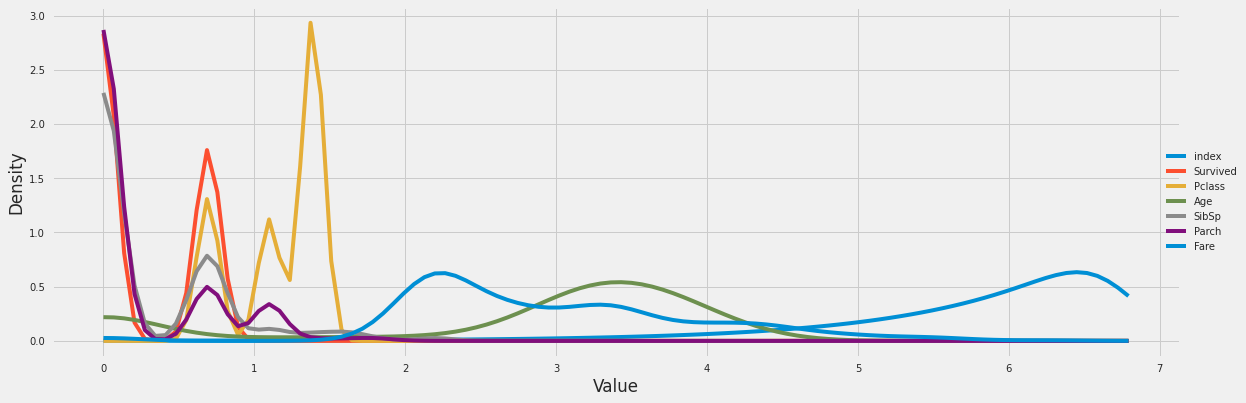

In [24]:
density_plot(log_counts_pd)

In [25]:
def quantile_norm(X):
    quantile = np.mean(np.sort(X, axis=0), axis=1) # quantile calculus
    rank = np.apply_along_axis(stats.rankdata, 0, X)
    rank_indices = rank.astype(np.int) - 1
    X_index = quantile[rank_indices]
    return X_index

def quantile_log(X):
    X_log = np.log(X + 1)
    Xi_log = quantile_norm(X_log)
    Xi_log_pd = pd.DataFrame(Xi_log, columns=X.columns)
    return Xi_log_pd

In [26]:
count_normalized = quantile_log(counts)

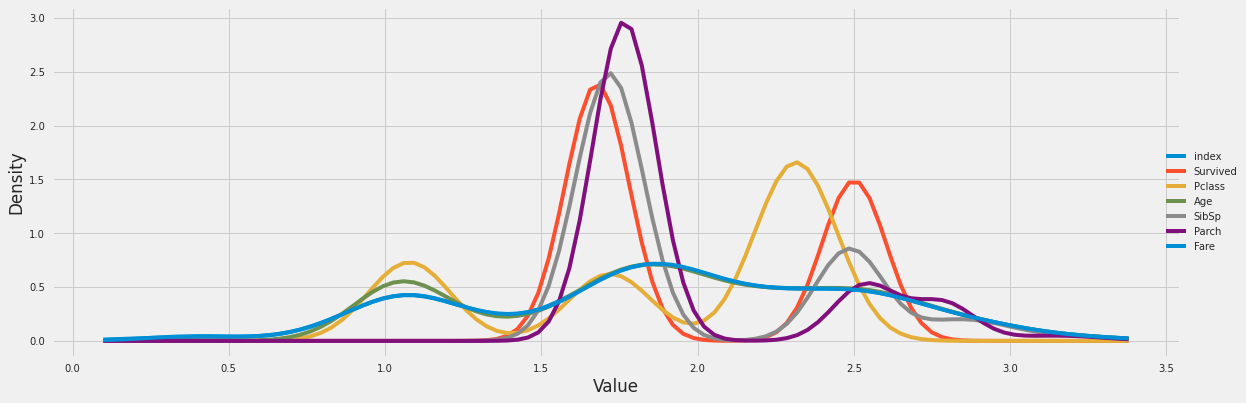

In [27]:
density_plot(count_normalized)

In [28]:
def most_variable_rows(data, *arg):
    rowvar = np.var(data, axis=1)
    sort_indices = np.argsort(rowvar)
    variable_data = data[sort_indices, :]
    return variable_data

from scipy.cluster.hierarchy import linkage

def bicluster(data, linkage_method='average', distance_metric='correlation'):
    y_rows = linkage(data, method=linkage_method, metric=distance_metric)
    y_cols = linkage(data.T, method=linkage_method, metric=distance_metric)
    return y_rows, y_cols

In [29]:
from scipy.cluster.hierarchy import dendrogram, leaves_list

def clear_spines(axes):
    for loc in ['left', 'right', 'top', 'bottom']:
        axes.spines[loc].set_visible(False)
    axes.set_xticks([])
    axes.set_yticks([])

def plot_bicluster(data, row_linkage, col_linkage, row_nclusters=10, col_nclusters=5):
    fig = plt.figure(figsize=(10, 10))
    
    ax1 = fig.add_axes([0.09, 0.1, 0.2, 0.6])
    
    threshold_r = (row_linkage[-row_nclusters, 2] +
                   row_linkage[-row_nclusters+1, 2]) / 2
    with plt.rc_context({'lines.linewidth': 0.75}):
        dendrogram(row_linkage, orientation='left',
                   color_threshold=threshold_r, ax=ax1)
    clear_spines(ax1)
    
    ax2 = fig.add_axes([0.3, 0.71, 0.6, 0.2]) 
    threshold_c = (col_linkage[-col_nclusters, 2] +
                   col_linkage[-col_nclusters+1, 2]) / 2
    with plt.rc_context({'lines.linewidth': 0.75}):
        dendrogram(col_linkage,
                   color_threshold=threshold_c, ax=ax2)
    clear_spines(ax2)
    
    ax = fig.add_axes([0.3, 0.1, 0.6, 0.6])
    
    idx_rows = leaves_list(row_linkage)
    data = data[idx_rows, :]
    idx_cols = leaves_list(col_linkage)
    data = data[:, idx_cols]
    
    im = ax.imshow(data, aspect='auto', origin='lower', cmap='YlGnBu_r')
    clear_spines(ax)
    
    ax.set_xlabel('Columns')
    ax.set_ylabel('Index', labelpad=150)
    axcolor = fig.add_axes([0.91, 0.1, 0.02, 0.6])
    plt.colorbar(im, cax=axcolor)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:42: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


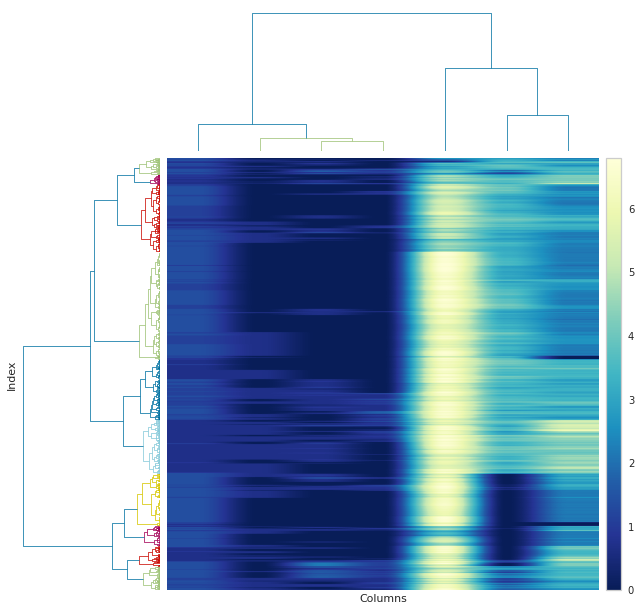

In [30]:
count_log = np.log(counts_nd + 1)
count_var = most_variable_rows(count_log)

yr, yc = bicluster(count_var, linkage_method='ward', distance_metric='euclidean')

plot_bicluster(count_var, yr, yc)

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">Pre-Processing & Feature Enginiering</p>

# Pre-Processing & Feature Enginiering
- All possible features
- Pipeline 
1. **Data cleaning**
    - Fix or remove outliers
    - Fill missing values (0, mean, median)
3. **Feature engineering**
    - Discretization of continuous value features
    - Decomposition of features (categorical)
    - Add transformations that are expected to be effective on features (log(x), sqrt(x), x**2)
    - Aggregate the features to create new features
4. **Feature scaling**
    - Standardization and normalization of features

In [31]:
data.isnull().sum(), main_test.reset_index().isnull().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 dtype: int64,
 index            0
 PassengerId      0
 Pclass           0
 Name             0
 Sex              0
 Age             86
 SibSp            0
 Parch            0
 Ticket           0
 Fare             1
 Cabin          327
 Embarked         0
 dtype: int64)

In [32]:
cluster_data['FamilySize'] = cluster_data['SibSp'] + cluster_data['Parch'] + 1
cluster_data['IsAlone'] = np.where(cluster_data['FamilySize'] <= 1, 1, 0)
cluster_data.loc[cluster_data['FamilySize'] > 0, 'travelled_alone'] = 'No'
cluster_data.loc[cluster_data['FamilySize'] == 0, 'travelled_alone'] = 'Yes'

cluster_data['Honorific'] = cluster_data.Name.str.split(',', -1,
                                                        expand=True)[1].str.split('.', 1,
                                                                                  expand=True)[0].str.strip().replace({'Mlle': 'Miss','Ms': 'Miss', 'Lady': 'Noble', 'Don': 'Noble',
                                                                                                                       'Jonkheer': 'Noble', 'the Countess': 'Noble', 'Sir': 'Noble',
                                                                                                                       'Countess': 'Noble',
                                                                                                                       'Mme': 'Mrs', 'Capt': 'Soldier', 'Major': 'Soldier', 'Col': 'Soldier', 
                                                                                                                       'Rev': 'Mr', 'Dr': 'Mr', 'Dona': 'Noble', 'Master': 'Soldier'})
cluster_data['FamilyName'] = cluster_data.Name.str.split(',', -1, expand=True)[0]
cluster_data['FullName'] = cluster_data.Name.str.split(',', -1, expand=True)[1].str.split('.', 1, expand=True)[1].str.strip()
cluster_data['FirstName'] = cluster_data.FullName.str.split(' ', 1, expand=True)[0].str.strip('(').str.strip(')')
cluster_data['NameLength'] = cluster_data.FullName.apply(lambda x: len(x))
cluster_data['Surname'] = cluster_data.Name.str.extract(r'([A-Za-z]+),', expand=False)
cluster_data['TicketPrefix'] = cluster_data.Ticket.str.extract(r'(.*\d)', expand=False)
cluster_data['SurnameTicket'] = cluster_data['Surname'] + cluster_data['TicketPrefix']
cluster_data['IsFamily'] = cluster_data.SurnameTicket.duplicated(keep=False).astype(int)
cluster_data['Child'] = cluster_data.Age.map(lambda x: 1 if x <=16 else 0)


bins = [0, 2, 12, 17, 60, np.inf]
labels = ['baby', 'child', 'teenager', 'adult', 'elderly']
age_groups = pd.cut(cluster_data.Age, bins, labels=labels)
cluster_data['AgeGroup'] = age_groups

#Cont_Features = ['Age', 'Fare']
#num_bins = 5
#for feature in Cont_Features:
#    bin_feature = feature + 'Bin'
#    cluster_data[bin_feature] = pd.qcut(cluster_data[feature], num_bins)
#    label = LabelEncoder()
#    cluster_data[bin_feature] = label.fit_transform(cluster_data[bin_feature])


cluster_data['Age*Class'] = cluster_data.Age * cluster_data.Pclass


FamilyWithChild = cluster_data[(cluster_data.IsFamily == 1) & (cluster_data.Child == 1)]['SurnameTicket'].unique()
cluster_data['FamilyId'] = 0
for ind, identifier in enumerate(FamilyWithChild):
    cluster_data.loc[cluster_data.SurnameTicket == identifier, ['FamilyId']] = ind + 1

cluster_data['FamilySurvival'] = 1
Survived_by_FamilyId = cluster_data.groupby('FamilyId').Survived.sum()
for i in range(1, len(FamilyWithChild)+1):
    if Survived_by_FamilyId[i] >= 1:
        cluster_data.loc[cluster_data.FamilyId == i, ['FamilySurvival']] = 2
    elif Survived_by_FamilyId[i] == 0:
        cluster_data.loc[cluster_data.FamilyId == i, ['FamilySurvival']] = 0


cluster_data.drop('Name', axis=1, inplace=True)
cabin_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 1, 'M': 8}
cluster_data['Deck'] = cluster_data['Cabin'].str[0].fillna('M').replace(cabin_map)
cluster_data['Ticket'] = cluster_data['Ticket'].str.split(' ').str.get(-1).str.get(0).str.replace('L', '2').astype(np.int64)


cat_features = cluster_data.columns[~cluster_data.columns.isin(['Survived', 'Fare', 'FamilySize', 'Pclass',
                                                                'PassengerId', 'Age', 'Ticket', 'Parch', 'Cabin',
                                                                'Embarked'])]
cluster_data = pd.get_dummies(cluster_data, columns=cat_features)
dummie_data = cluster_data.reset_index()

dummie = pd.get_dummies(dummie_data['Cabin'])
data_dummie = dummie_data.drop(['Cabin'], axis=1).join(pd.DataFrame(dummie.sum(axis=1), columns=['Cabin']))
data_rep = data_dummie.fillna({'Age': data_dummie['Age'].mean(), 'Embarked': data_dummie['Embarked'].fillna(method='ffill'), 'Fare': data_dummie['Fare'].mean()})
data_rep['Fare'] = data_rep['Fare'].round().astype(np.int64)
data_rep['Age'] = data_rep['Age'].astype(np.int64)
data_rep['Fare'].where((np.abs(data_rep['Fare']) < data_rep['Fare'].quantile(0.997, )), 500, inplace=True) # 300

data_rep_cluster = data_rep.drop('Survived', axis=1)
data_rep.drop(['index', 'PassengerId'], axis=1,  inplace=True)

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:200%;text-align:center;border-radius:10px 10px;">Data Splitting</p>

## Train & Test

>Divided into Train set used for Model training and data to make predictions.

In [33]:
train = data_rep.iloc[cluster_data_c.index]
test = data_rep.iloc[cluster_main_test.index+cluster_data_c.shape[0]].drop(columns=['Survived'])
X = train.drop(columns='Survived', axis=1) # .to_numpy()
y = train['Survived'] # .to_numpy()

data_labels = y.to_numpy()

In [34]:
data_num = X.drop(["Embarked"], axis=1)
number_attribs = list(data_num)

In [35]:
categorie_attribs = ["Embarked"] 

number_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

cluster_test_pipeline = ColumnTransformer([
    ("number", number_pipeline, number_attribs),
    ("categorie", OneHotEncoder(), categorie_attribs),
])

In [36]:
cluster_data_prepared = cluster_test_pipeline.fit_transform(X)
cluster_main_test = cluster_test_pipeline.transform(test)

In [37]:
X_train, X_val, y_train, y_val = train_test_split(cluster_data_prepared, data_labels, test_size=0.25, stratify=data_labels)

----------
## Feature Importance Sample

In [38]:
#model = RandomForestClassifier()
#model.fit(X_train, y_train)

In [39]:
#model.feature_importances_.shape

In [40]:
#model = CatBoostClassifier(verbose=False)

In [41]:
#X_c = X[['Age', 'Parch', 'Ticket', 'Fare', 'FamilySize']]
#y_c = y

In [42]:
#model.fit(X_c, y_c)

In [43]:
#importance = pd.DataFrame({'feature': X_c.columns, 'importance': model.feature_importances_})

In [44]:
#importance.sort_values('importance', ascending=False).set_index('feature').plot(kind='barh')

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">PCA</p>

# PCA
>Dimensionality reduction is performed for the specified variance by PCA because of the large number of features. This will automate the mechanical manipulation of factor contributions that can maintain the variance.
>Dimensionality reduction is not an optimal solution because it may remove features that are necessary for prediction. This operation has an experimental component only.

In [45]:
pca_e = PCA().fit(cluster_data_prepared)
cumsum = np.cumsum(pca_e.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

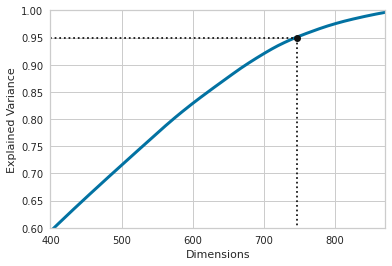

In [46]:
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([400, 871, 0.6, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.grid(True)

In [47]:
pca = PCA(n_components=0.95)
cluster_data_prepared_pca = pca.fit_transform(cluster_data_prepared)
cluster_main_test_pca = pca.transform(cluster_main_test)

In [48]:
cluster_data_prepared_pca = pd.DataFrame(cluster_data_prepared_pca)
cluster_main_test_pca = pd.DataFrame(cluster_main_test_pca)

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">Feature Clustering</p>

>The PCA (dimensionality reduction) described above may have removed features that may have been necessary, but by clustering the data with a lower order and adding them as features, feature clustering is performed so that the model can recognize patterns better.

- In the following, we use the automated ElbowScore, but if you want to create your own, you can implement InertiaScore or SilhouetteScore.

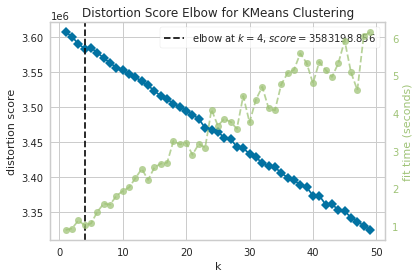

In [49]:
model = KMeans(init="k-means++", n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 50)) #100
visualizer.fit(cluster_data_prepared_pca)
visualizer.show();

In [50]:
#spect_1_cluster_data = SpectralClustering(n_clusters=visualizer.elbow_value_).fit_predict(cluster_data_prepared_pca)# visualizer.elbow_value_
#spect_1_cluster_test = SpectralClustering(n_clusters=visualizer.elbow_value_).fit_predict(cluster_main_test_pca)# visualizer.elbow_value_

In [51]:
spect_cluster_data = KMeans(n_clusters=visualizer.elbow_value_).fit_predict(cluster_data_prepared_pca) # k=36
spect_cluster_test = KMeans(n_clusters=visualizer.elbow_value_).fit_predict(cluster_main_test_pca) # k=36

>The following feature clusters can be assigned to the data after processing. It can also be done experimentally.

>The following data is assigned to the data assuming PCA and converted again by Pipeline.

In [52]:
X['Cluster'] = spect_cluster_data

In [53]:
X.iloc[:, :9].head(10).style.background_gradient(cmap='mako_r', text_color_threshold=0.02)

,Pclass,Age,Parch,Ticket,Fare,Embarked,FamilySize,Sex_female,Sex_male
0,3,22,0,2,7,S,2,0,1
1,1,38,0,1,71,C,2,1,0
2,3,26,0,3,8,S,1,1,0
3,1,35,0,1,53,S,2,1,0
4,3,35,0,3,8,S,1,0,1
5,3,29,0,3,8,Q,1,0,1
6,1,54,0,1,52,S,1,0,1
7,3,2,1,3,21,S,5,0,1
8,3,27,2,3,11,S,3,1,0
9,2,14,0,2,30,C,2,1,0


In [54]:
test['Cluster'] = spect_cluster_test

In [55]:
test.iloc[:, :9].head(10).style.background_gradient(cmap='mako_r', text_color_threshold=0.02)

,Pclass,Age,Parch,Ticket,Fare,Embarked,FamilySize,Sex_female,Sex_male
891,3,34,0,3,8,Q,1,0,1
892,3,47,0,3,7,S,2,1,0
893,2,62,0,2,10,Q,1,0,1
894,3,27,0,3,9,S,1,0,1
895,3,22,1,3,12,S,3,1,0
896,3,14,0,7,9,S,1,0,1
897,3,30,0,3,8,Q,1,1,0
898,2,26,1,2,29,S,3,0,1
899,3,18,0,2,7,C,1,1,0
900,3,21,0,4,24,S,3,0,1


In [56]:
#X['cut_bin'] = pd.cut(X["Cluster"], 
#                      bins=np.round(np.log(len(X['Cluster']))).astype(int),  # Sturgess Formula : k=log2N+1 
#                      labels=[1, 2, 3, 4, 5, 6, 7], precision=2) # 0~7labels=[1, 2, 3, 4, 5, 6, 7]

In [57]:
#test['cut_bin'] = pd.cut(test["Cluster"], 
#                      bins=np.round(np.log(len(X['Cluster']))).astype(int),  # Sturgess Formula : k=log2N+1 
#                      labels=[1, 2, 3, 4, 5, 6, 7], precision=2) # 0~7labels=[1, 2, 3, 4, 5, 6, 7]

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">Final Transform</p>

In [58]:
data_prepared = cluster_test_pipeline.fit_transform(X)

In [59]:
cluster_main_test = cluster_test_pipeline.transform(test)

In [60]:
X_train, X_val, y_train, y_val = train_test_split(data_prepared, data_labels, test_size=0.25, stratify=data_labels)

-----
<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:300%;text-align:center;border-radius:10px 10px;">Model</p>

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:200%;text-align:center;border-radius:10px 10px;">GridSearch RandomizedSearch</p>

# Model
- A grid search is used to narrow down the rough range, and a random search is used to further understand the detailed values and obtain the hyperparameters of the model.

-----
<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:200%;text-align:center;border-radius:10px 10px;">Best Score Model</p>

### **GradientBoosting** 

In [61]:
#gb_model = GradientBoostingClassifier()
#gb_param_grid = {'learning_rate':[0.1, 0.01, 0.001], 'max_depth':[5, 10], 'n_estimators':[10, 100, 200, 300]}
#gb_model.get_params().keys()

In [62]:
#gb_s_model = GridSearchCV(gb_model, gb_param_grid, cv=10, scoring='accuracy')
#gb_s_model.fit(X_train, y_train)

In [63]:
#gb_s_model.best_params_
#{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} samples=10000
gb_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=100) # warm_start=True
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5)

In [64]:
#gb = gb_s_model.best_estimator_
y_pred_gb = gb_model.predict(X_val)

Precision : 0.8157894736842105 / Recall : 0.7209302325581395
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87       137
         1.0       0.82      0.72      0.77        86

    accuracy                           0.83       223
   macro avg       0.83      0.81      0.82       223
weighted avg       0.83      0.83      0.83       223



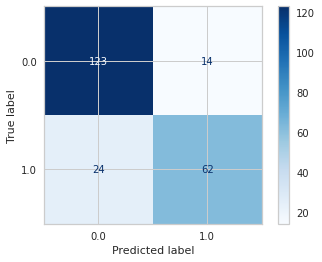

In [65]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_gb), recall_score(y_val, y_pred_gb)))
print(classification_report(y_val, y_pred_gb))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_gb), display_labels=gb_model.classes_)
disp.plot(cmap='Blues');

In [66]:
main_pred_gb = gb_model.predict(cluster_main_test)

In [67]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': main_pred_gb.astype(int)}).to_csv('submission_test.csv', index=0) # 0.80143

In [68]:
kfold_1 =StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [69]:
y_score = cross_val_predict(gb_model, X_train, y_train, cv=kfold_1, method='decision_function')

In [70]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precision[:-1], "b--", label="Precision") # [:-1]
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall") # [:-1]
    plt.legend()

In [71]:
precision, recall, thresholds = precision_recall_curve(y_train, y_score)

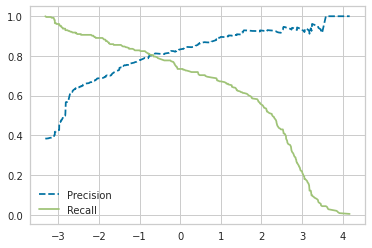

In [72]:
plot_precision_recall_vs_threshold(precision, recall, thresholds)

In [73]:
threshold_90_precision = thresholds[np.argmax(precision >= 0.80)] # 0.85 # 0.80
threshold_90_precision

-0.7564859800681232

In [74]:
y_train_pred_90 = (y_score >= threshold_90_precision)

In [75]:
y_train_pred_90.shape # y_train

(668,)

In [76]:
gb_model.fit(X_train, y_train_pred_90)

GradientBoostingClassifier(max_depth=5)

In [77]:
y_pred_90_gb = gb_model.predict(X_val)

Precision : 0.7777777777777778 / Recall : 0.7325581395348837
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85       137
         1.0       0.78      0.73      0.75        86

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.82      0.82       223



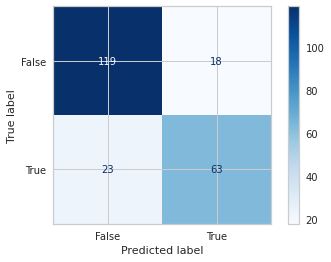

In [78]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_90_gb), recall_score(y_val, y_pred_90_gb)))
print(classification_report(y_val, y_pred_90_gb))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_90_gb), display_labels=gb_model.classes_)
disp.plot(cmap='Blues');

In [79]:
main_pred_90_gb = gb_model.predict(cluster_main_test)

In [80]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': main_pred_90_gb.astype(int)}).to_csv('submission_best.csv', index=0)

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:200%;text-align:center;border-radius:10px 10px;">early stopping</p>

- One way to regularize a model
- In stochastic gradient descent and mini-batch gradient descent methods, the curve is not as smooth as in batch gradient descent, and there is a risk of being caught in a local minimum. Therefore, if the verification error keeps rising above the minimum for a while, we can construct a syntax to roll back to the last minimum.
- Early termination can also be used in boosting algorithms to find the optimal number of decision trees.

In [81]:
errors = [precision_score(y_val, y_pred)
          for y_pred in gb_model.staged_predict(X_val)]

In [82]:
bst_n_estimators = np.argmax(errors) + 1

In [83]:
bst_n_estimators

3

In [84]:
gb_best = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=bst_n_estimators)

In [85]:
gb_best.fit(X_train, y_train_pred_90)

GradientBoostingClassifier(max_depth=5, n_estimators=3)

In [86]:
y_pred_90_gb_best = gb_model.predict(X_val)

Precision : 0.7777777777777778 / Recall : 0.7325581395348837
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85       137
         1.0       0.78      0.73      0.75        86

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.82      0.82       223



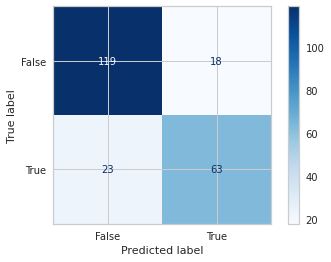

In [87]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_90_gb_best), recall_score(y_val, y_pred_90_gb_best)))
print(classification_report(y_val, y_pred_90_gb_best))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_90_gb_best), display_labels=gb_best.classes_)
disp.plot(cmap='Blues');

In [88]:
main_pred_90_gb_best = gb_best.predict(cluster_main_test)

In [89]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1),
#              'Survived': pd.DataFrame(main_pred_90_gb_best).replace({False: 0, True :1}).to_numpy().T[0]}).to_csv('submission_01.csv', index=0)

In [90]:
param_rand = {'learning_rate': reciprocal(0.001, 1), 
              'max_depth': randint(low=3, high=10)}

In [91]:
gb_best_rd = GradientBoostingClassifier(subsample=0.25, n_estimators=bst_n_estimators, warm_start=True)

In [92]:
rnd_search = RandomizedSearchCV(gb_best_rd, param_rand, n_iter=10, cv=kfold_1, scoring='f1')

In [93]:
rnd_search.fit(X_train, y_train_pred_90)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=GradientBoostingClassifier(n_estimators=3,
                                                        subsample=0.25,
                                                        warm_start=True),
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f042f905f10>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f042f905290>},
                   scoring='f1')

In [94]:
gb_best_p = GradientBoostingClassifier(learning_rate=0.12727932524008223, max_depth=3, subsample=0.25, n_estimators=bst_n_estimators, warm_start=True)

In [95]:
gb_best_p.fit(X_train, y_train_pred_90)

GradientBoostingClassifier(learning_rate=0.12727932524008223, n_estimators=3,
                           subsample=0.25, warm_start=True)

In [96]:
y_pred_90_gb_best_rnd = gb_best_p.predict(X_val)

Precision : 0.8051948051948052 / Recall : 0.7209302325581395
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86       137
         1.0       0.81      0.72      0.76        86

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.83      0.82       223



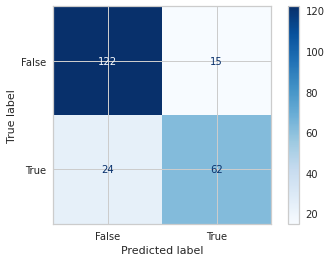

In [97]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_90_gb_best_rnd), recall_score(y_val, y_pred_90_gb_best_rnd)))
print(classification_report(y_val, y_pred_90_gb_best_rnd))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_90_gb_best_rnd), display_labels=gb_best_p.classes_)
disp.plot(cmap='Blues');

In [98]:
main_pred_90_gb_best_rnd = gb_best.predict(cluster_main_test)

In [99]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1),
#              'Survived': pd.DataFrame(main_pred_90_gb_best_rnd).replace({False: 0, True :1}).to_numpy().T[0]}).to_csv('submission_02.csv', index=0)

In [100]:
precision_score(y_train, y_train_pred_90)

0.8023255813953488

In [101]:
recall_score(y_train, y_train_pred_90)

0.80859375

In [102]:
fpr, tpr, thresholds_r = roc_curve(y_train_pred_90, y_score)

In [103]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')

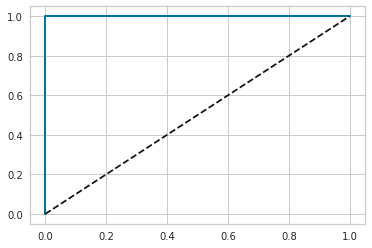

In [104]:
plot_roc_curve(fpr, tpr)

In [105]:
roc_auc_score(y_train_pred_90, y_score)

1.0

In [106]:
y_train_pred = cross_val_predict(gb_model, X_train, y_train_pred_90, cv=3)

In [107]:
cl_a, cl_b = 0, 1

In [108]:
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

<p style="background-color:#000000;font-family:Georgia;color:#FFFFFF;font-size:200%;text-align:center;border-radius:10px 10px;">Other Models</p>

### **AdaBoost**

In [109]:
#ada_model = AdaBoostClassifier() # estimators=DecisionTreeClassifier(max_depth=1) : Default
#ada_param_grid = {'learning_rate': [0.001, 0.01, 0.1, 1], 'n_estimators': [10, 100, 200, 300]}
#ada_model.get_params().keys()

In [110]:
#ada_s_model = GridSearchCV(ada_model, ada_param_grid, cv=10, scoring='accuracy')
#ada_s_model.fit(X_train, y_train)

In [111]:
#ada_s_model.best_params_
# {'learning_rate': 1, 'n_estimators': 100} samples=10000

#ada_model = AdaBoostClassifier(learning_rate=1, n_estimators=100) 
#ada_model.fit(X_train, y_train)
ada_model = AdaBoostClassifier(learning_rate=1, n_estimators=100) 
ada_model.fit(X_train, y_train_pred_90)

AdaBoostClassifier(learning_rate=1, n_estimators=100)

In [112]:
#ada = ada_s_model.best_estimator_
y_pred_ada = ada_model.predict(X_val)

Precision : 0.7976190476190477 / Recall : 0.7790697674418605
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       137
         1.0       0.80      0.78      0.79        86

    accuracy                           0.84       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223



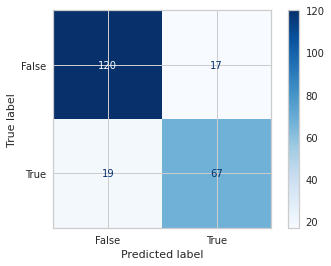

In [113]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_ada), recall_score(y_val, y_pred_ada)))
print(classification_report(y_val, y_pred_ada))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_ada), display_labels=ada_model.classes_)
disp.plot(cmap='Blues');

In [114]:
prediction_ada = ada_model.predict(cluster_main_test)

In [115]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': prediction_ada.astype(int)}).to_csv('submission_Ada_01.csv', index=0)

### RandomForestClassifier

In [116]:
#rand_model = RandomForestClassifier()
#rnd_param_grid = {'n_estimators': [40, 50, 55], 'max_depth': [90, 100, 150], 'max_samples': [1200, 1500, 1600]}
#rand_model.get_params().keys()

In [117]:
#rnd_model = GridSearchCV(rand_model, rnd_param_grid, cv=10, scoring='accuracy')
#rnd_model.fit(X_train, y_train)

In [118]:
#rnd_model.best_params_
#{'max_depth': 10, 'max_samples': 300, 'n_estimators': 100} sample=10000

In [119]:
#rand_model = rnd_model.best_estimator_
#rand_model = RandomForestClassifier(max_depth=90, max_samples=300, n_estimators=40)
#rand_model.fit(X_train, y_train)
#y_pred_rnd = rand_model.predict(X_val)

rand_model = RandomForestClassifier(max_depth=90, max_samples=300, n_estimators=40)
rand_model.fit(X_train, y_train_pred_90)
y_pred_rnd = rand_model.predict(X_val)

Precision : 0.7931034482758621 / Recall : 0.8023255813953488
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       137
         1.0       0.79      0.80      0.80        86

    accuracy                           0.84       223
   macro avg       0.83      0.84      0.83       223
weighted avg       0.84      0.84      0.84       223



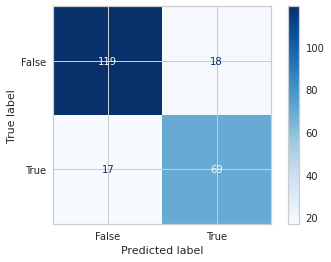

In [120]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_rnd), recall_score(y_val, y_pred_rnd)))
print(classification_report(y_val, y_pred_rnd))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_rnd), display_labels=rand_model.classes_)
disp.plot(cmap='Blues');

In [121]:
prediction_rand = rand_model.predict(cluster_main_test)

In [122]:
rand_model.fit(X_train, y_train_pred_90)

RandomForestClassifier(max_depth=90, max_samples=300, n_estimators=40)

In [123]:
y_pred_rnd_90 = rand_model.predict(X_val)

Precision : 0.7727272727272727 / Recall : 0.7906976744186046
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       137
         1.0       0.77      0.79      0.78        86

    accuracy                           0.83       223
   macro avg       0.82      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



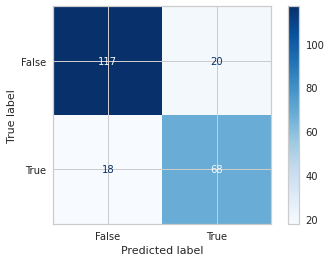

In [124]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_rnd_90), recall_score(y_val, y_pred_rnd_90)))
print(classification_report(y_val, y_pred_rnd_90))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_rnd_90), display_labels=rand_model.classes_)
disp.plot(cmap='Blues');

In [125]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': prediction_rand.astype(int)}).to_csv('submission_rand_01.csv', index=0)

### ExtraTreeClassifier

In [126]:
#ex_model = ExtraTreesClassifier()
#ex_grid_param = {'n_estimators': [10, 90, 100, 110], 'max_depth': [8, 9, 11, 14, 15, 30], 'max_samples': [90, 100, 260, 270]}

In [127]:
#ext_model = GridSearchCV(ex_model, ex_grid_param, cv=10, scoring='accuracy')
#ext_model.fit(X_train, y_train)

In [128]:
#ext_model.best_params_
# {'max_depth': 14, 'max_samples': 270, 'n_estimators': 110}
# {'max_depth': 30, 'max_samples': 270, 'n_estimators': 90} sample=10000
# {'max_depth': 30, 'max_samples': 270, 'n_estimators': 110}

In [129]:
#ext = ext_model.best_estimator_
#ex_model = ExtraTreesClassifier(max_depth=30, max_samples=270, n_estimators=110)
#ex_model.fit(X_train, y_train)
#y_pred_ext = ex_model.predict(X_val)

ex_model = ExtraTreesClassifier(max_depth=30, max_samples=270, n_estimators=110)
ex_model.fit(X_train, y_train_pred_90)
y_pred_ext = ex_model.predict(X_val)

Precision : 0.7931034482758621 / Recall : 0.8023255813953488
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       137
         1.0       0.79      0.80      0.80        86

    accuracy                           0.84       223
   macro avg       0.83      0.84      0.83       223
weighted avg       0.84      0.84      0.84       223



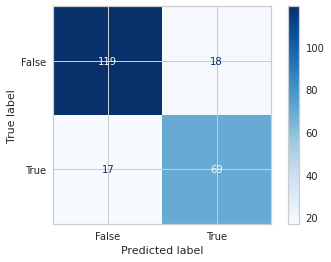

In [130]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_ext), recall_score(y_val, y_pred_ext)))
print(classification_report(y_val, y_pred_ext))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_ext), display_labels=ex_model.classes_)
disp.plot(cmap='Blues');

In [131]:
prediction_ex = ex_model.predict(cluster_main_test)

In [132]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': prediction_ex.astype(int)}).to_csv('submission_ext_01.csv', index=0)

### SVM

In [133]:
#svm_model=SVC(kernel='rbf', probability=True) # kernel='rbf', probability=True
#tuned_param = {'gamma': [0.005,0.01,0.05,0.1,1],'C':[0.1,1,5,10]}

In [134]:
#svc_model = GridSearchCV(svm_model, tuned_param, cv=10, scoring='accuracy')
#svc_model.fit(X_train, y_train)

In [135]:
#svc_model.best_params_

In [136]:
#svc = svc_model.best_estimator_
#svm_model=SVC(kernel='rbf', probability=True, C=5, gamma=1)
#svm_model.fit(X_train, y_train)
#y_pred = svm_model.predict(X_val)

In [137]:
#print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred), recall_score(y_val, y_pred)))
#print(classification_report(y_val, y_pred))
#disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred), display_labels=svc.classes_)
#disp.plot(cmap='Blues');

### XGBoost

In [138]:
#xgb_boost = XGBClassifier(use_label_encoder=False, eval_metric='auc')
#xgb_boost.fit(X_train, y_train)
#y_pred_xgb = xgb_boost.predict(X_val)

xgb_boost = XGBClassifier(use_label_encoder=False, eval_metric='auc')
xgb_boost.fit(X_train, y_train_pred_90)
y_pred_xgb = xgb_boost.predict(X_val)

Precision : 0.7701149425287356 / Recall : 0.7790697674418605
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86       137
         1.0       0.77      0.78      0.77        86

    accuracy                           0.83       223
   macro avg       0.82      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



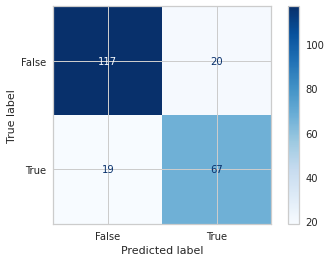

In [139]:
print('Precision : {} / Recall : {}'.format(precision_score(y_val, y_pred_xgb), recall_score(y_val, y_pred_xgb)))
print(classification_report(y_val, y_pred_xgb))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred_xgb), display_labels=xgb_boost.classes_)
disp.plot(cmap='Blues');

In [140]:
prediction_xgb = xgb_boost.predict(cluster_main_test)

In [141]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': prediction_xgb.astype(int)}).to_csv('submission_xgb_01.csv', index=0)

In [142]:
xgb_boost = XGBClassifier(use_label_encoder=False, eval_metric='auc', learning_rate=0.01, max_depth=3, n_estimators=200)
xgb_boost.fit(X_train, y_train_pred_90)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='auc', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=3, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=200, n_jobs=4,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [143]:
prediction_xgb_test = xgb_boost.predict(cluster_main_test)

In [144]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': prediction_xgb_test}).to_csv('submission_xgb_02.csv', index=0)

### VotingClassifier

In [145]:
rf = RandomForestClassifier()
logr = LogisticRegression()
xgb = XGBClassifier(eval_metric='mlogloss')
dtree= DecisionTreeClassifier(random_state = 0)
ex_model = ExtraTreesClassifier()
gb_model = GradientBoostingClassifier()
ada_model = AdaBoostClassifier(learning_rate=1, n_estimators=100) 

knn = KNeighborsClassifier()
svc = SVC(probability=True)
ridge_c = RidgeClassifier()

In [146]:
kfold =StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [147]:
def score_model_class(model, params ,scoring = "f1_macro"):
    
    model = GridSearchCV(model, param_grid=params, scoring=scoring, cv=kfold)
    
    model.fit(X_train, y_train_pred_90) # y_train_pred_90
    y_pred = model.predict(X_val)
    
    print ("Model and params: ", model.best_estimator_, model.best_params_) 
    print("\n")
    print("Train f1 score: ", model.best_score_)
    print("test f1_score: ",f1_score(y_val, y_pred))
    print("\n")
    print("Test Report:")
    print(classification_report(y_val, y_pred))
    return model

In [148]:
ridge_params = {"max_iter": [120, 200,300], "alpha":[0.1,0.8, 1,1.5, 2,3]}
logr_params = {"solver":["liblinear","saga", "lbfgs", "newton-cg"],
    "penalty": ["l2","l1", "elasticnet", "none"],
    "C": [0.01,0.5,1,3,4],
    "max_iter": [4000]
}
xgb_params={'learning_rate': [0.05,0.01,0.1, 1], 
           # "subsample": [0.5, 0.7, 1.0],
            'max_depth': [2, 3, 5, 7],
            #"gamma" : [3,4,5,6] ,             
            'n_estimators': [150, 200, 300, 500]
           }
forest_params = {     
    "max_depth" : [10,20,30,40],       
    "n_estimators" : [300,350,400,410,420,440],
    "max_features" :["auto", "log2", None]
}
tree_params = { "max_depth" : [8,10,20,30],       
    "max_features" :["auto", "log2", None]}

knn_params = {"n_neighbors" : [2,3,5] , "metric" :["euclidean", "manhattan", "minkowski"], "weights" :["uniform", "distance"]}
svc_params = {"kernel" : ["linear", "poly", "rbf", "sigmoid"], "C" : [ 0.001, 0.1, 1, 2, 3], "gamma":["scale", "auto"]}

In [149]:
ex_m = score_model_class(ex_model, {'max_depth': [30], 'max_samples': [270], 'n_estimators': [110]})

Model and params:  ExtraTreesClassifier(max_depth=30, max_samples=270, n_estimators=110) {'max_depth': 30, 'max_samples': 270, 'n_estimators': 110}


Train f1 score:  0.9165571960106685
test f1_score:  0.7931034482758621


Test Report:
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.87       137
         1.0       0.78      0.80      0.79        86

    accuracy                           0.84       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223



In [150]:
ada_m = score_model_class(ada_model, {'learning_rate': [1], 'n_estimators': [100]}) 

Model and params:  AdaBoostClassifier(learning_rate=1, n_estimators=100) {'learning_rate': 1, 'n_estimators': 100}


Train f1 score:  0.9290554241096396
test f1_score:  0.788235294117647


Test Report:
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       137
         1.0       0.80      0.78      0.79        86

    accuracy                           0.84       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223



In [151]:
#ridge_m = score_model_class (ridge_c, ridge_params)
ridge_m = score_model_class(ridge_c, {'alpha': [1.2, 1.5, 2], 'max_iter': [2]})

Model and params:  RidgeClassifier(alpha=1.2, max_iter=2) {'alpha': 1.2, 'max_iter': 2}


Train f1 score:  0.7979805546915395
test f1_score:  0.7080745341614907


Test Report:
              precision    recall  f1-score   support

         0.0       0.80      0.87      0.84       137
         1.0       0.76      0.66      0.71        86

    accuracy                           0.79       223
   macro avg       0.78      0.77      0.77       223
weighted avg       0.79      0.79      0.79       223



In [152]:
#logr_m = score_model_class(logr, logr_params)
ex_m = score_model_class(ex_model, {'max_depth' : [30], 'max_samples' : [270], 'n_estimators': [110]})

Model and params:  ExtraTreesClassifier(max_depth=30, max_samples=270, n_estimators=110) {'max_depth': 30, 'max_samples': 270, 'n_estimators': 110}


Train f1 score:  0.9164544492881482
test f1_score:  0.7976878612716762


Test Report:
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       137
         1.0       0.79      0.80      0.80        86

    accuracy                           0.84       223
   macro avg       0.83      0.84      0.83       223
weighted avg       0.84      0.84      0.84       223



In [153]:
#rf_m =random_forest = score_model_class(rf, forest_params)
rf_m = score_model_class(rf, {'max_depth': [90], 'max_samples': [300], 'n_estimators': [100]})

Model and params:  RandomForestClassifier(max_depth=90, max_samples=300) {'max_depth': 90, 'max_samples': 300, 'n_estimators': 100}


Train f1 score:  0.9143107808846682
test f1_score:  0.7840909090909092


Test Report:
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       137
         1.0       0.77      0.80      0.78        86

    accuracy                           0.83       223
   macro avg       0.82      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



In [154]:
#dtree_m = score_model_class(dtree, tree_params)
dtree_m = score_model_class(dtree, {'max_depth': [50], 'max_features': [60]})

Model and params:  DecisionTreeClassifier(max_depth=50, max_features=60, random_state=0) {'max_depth': 50, 'max_features': 60}


Train f1 score:  0.8270382179221348
test f1_score:  0.6585365853658537


Test Report:
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80       137
         1.0       0.69      0.63      0.66        86

    accuracy                           0.75       223
   macro avg       0.74      0.73      0.73       223
weighted avg       0.75      0.75      0.75       223



In [155]:
#xgb_m = score_model_class(xgb, xgb_params)
xgb_m = score_model_class(xgb, {'learning_rate': [0.01], 'max_depth': [3], 'n_estimators': [200]})

Model and params:  XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='mlogloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=3, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=200, n_jobs=4,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None) {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


Train f1 score:  0.9445826648732686
test f1_score:  0.7590361445783131


Test Report:
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       137
         1.0       0.79      0.73      0.76        86

    accuracy 

In [156]:
#knn_m = score_model_class(knn, knn_params)
knn_m = score_model_class(knn, {'metric': ['manhattan'], 'n_neighbors': [5], 'weights': ['distance']})

Model and params:  KNeighborsClassifier(metric='manhattan', weights='distance') {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


Train f1 score:  0.5593990762106011
test f1_score:  0.336283185840708


Test Report:
              precision    recall  f1-score   support

         0.0       0.66      0.94      0.77       137
         1.0       0.70      0.22      0.34        86

    accuracy                           0.66       223
   macro avg       0.68      0.58      0.56       223
weighted avg       0.68      0.66      0.61       223



In [157]:
#svc_m = score_model_class(svc, svc_params)
svc_m = score_model_class(svc, {'C': [2], 'gamma': ['scale'], 'kernel': ['sigmoid']})

Model and params:  SVC(C=2, kernel='sigmoid', probability=True) {'C': 2, 'gamma': 'scale', 'kernel': 'sigmoid'}


Train f1 score:  0.8101655714679279
test f1_score:  0.7195121951219512


Test Report:
              precision    recall  f1-score   support

         0.0       0.81      0.86      0.84       137
         1.0       0.76      0.69      0.72        86

    accuracy                           0.79       223
   macro avg       0.79      0.77      0.78       223
weighted avg       0.79      0.79      0.79       223



In [158]:
gb_m = score_model_class(gb_model, {'learning_rate': [0.1], 'max_depth': [5], 'n_estimators': [100]})

Model and params:  GradientBoostingClassifier(max_depth=5) {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


Train f1 score:  0.9443846417728811
test f1_score:  0.7664670658682634


Test Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86       137
         1.0       0.79      0.74      0.77        86

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.83      0.82       223



In [159]:
vc = VotingClassifier([#("knn_m", knn_m), 
                       #("svc_m", svc_m),
                       ("xgb_m",xgb_m),
                       #("ridge_m", ridge_m),
                       #("dtree_m", dtree_m),
                       ("ex_m", ex_m),
                       ("rf_m", rf_m), 
                       ("gb_m", gb_m), ("ada_m", ada_m)],
                      voting = "soft")# hard

vc.fit(X_train,y_train)

VotingClassifier(estimators=[('xgb_m',
                              GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                           estimator=XGBClassifier(base_score=None,
                                                                   booster=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=None,
                                                                   enable_categorical=False,
                                                                   eval_metric='mlogloss',
                                                                   gamma=None,
                                                                   gpu_id=None,
                                                                   importanc

In [160]:
print("training: ", vc.score(X_train,y_train))
print(classification_report(y_val,vc.predict(X_val)))

training:  0.9610778443113772
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87       137
         1.0       0.81      0.73      0.77        86

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.82       223
weighted avg       0.83      0.83      0.83       223



In [161]:
y_sub = vc.predict(cluster_main_test)
sub = pd.DataFrame({'PassengerId': test.index, 'Survived': y_sub})
sub["Survived"] = sub["Survived"].astype(int)

In [162]:
#pd.DataFrame({'PassengerId': np.arange(892, 1310, 1), 'Survived': y_sub.astype(int)}).to_csv('submission_VT_01.csv', index=0)

- Thank you for Reading. 
- Please give me an UPVOTE if you can. Your UPVOTE will be a great encouragement to me